# 积分与数值积分

学习目标：把变化率转为累积量，理解定积分与原函数的关系，并按函数或离散采样数据选择求积方法、核对误差和单位。

前置知识：函数、极限、导数、有限求和；Python 函数、数组与模块导入。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

物理量示例均为教学模拟；其余函数与坐标无物理单位。

本章同时处理有限区间累积与反常积分，区分截断误差、求积误差及收敛性。

## 1 从变化率计算累积量

一辆模拟小车的速度为 $v(t)=1+2t$，其中 $t$ 是以秒为单位的时间数值，$v$ 的单位为 m/s，考虑 $0\le t\le2$。若每小段内暂用一个速度代表，位移近似为“速度乘时长”的总和。

把 2 秒分成 4 段，每段 0.5 秒。速度递增，使用左端速度会低估，使用右端速度会高估；这两个判断依赖本例的单调性。用中点速度得到 6 m，是这条线性速度曲线的特殊结果，不表示中点近似对任意函数都精确。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

times = np.linspace(0, 2, 5)
width = 0.5
left_speeds = 1 + 2 * times[:-1]
right_speeds = 1 + 2 * times[1:]
midpoints = (times[:-1] + times[1:]) / 2

print("左端近似（m）：", np.sum(left_speeds * width))  # 5。
print("右端近似（m）：", np.sum(right_speeds * width))  # 7。
print("中点近似（m）：", np.sum((1 + 2 * midpoints) * width))  # 6。

左端近似（m）： 5.0
右端近似（m）： 7.0
中点近似（m）： 6.0


## 2 定积分是细分极限

设实函数 $f$ 定义在有限闭区间 $[a,b]$，$a<b$。取正整数 $n$，等分宽度 $h=(b-a)/n$，端点 $x_i=a+ih$，其中 $i=0,\ldots,n$。在第 $i$ 段取样点 $x_i^*\in[x_{i-1},x_i]$，形成黎曼和（Riemann sum）：

$$S_n=\sum_{i=1}^{n}f(x_i^*)h.$$

当细分越来越细，若这些和趋向与取样方式无关的同一个有限数，就得到定积分

$$\int_a^b f(x)\,dx=\lim_{n\to\infty}S_n.$$

$f$ 是被积函数，$a,b$ 是积分下限和上限，$x$ 是积分变量，dx 标明对哪个变量积分。积分变量可改名，不改变这个数。连续函数在有限闭区间上可积；连续是充分条件，不是必要条件。

若使用不等宽分割，应让最大一段的宽度趋于零，不能只增加某一小块中的分段数。以下有限次计算只展示趋近趋势，不替代极限定义或可积性的证明。

In [2]:
for n in [4, 20, 100]:
    edges = np.linspace(0, 2, n + 1)
    h = 2 / n
    left_sum = np.sum((1 + 2 * edges[:-1]) * h)
    right_sum = np.sum((1 + 2 * edges[1:]) * h)
    print(f"n={n:3d}，左端={left_sum:.4f}，右端={right_sum:.4f}")  # 左右端点和从 (5, 7) 变为 (5.8, 6.2)、(5.96, 6.04)，夹住位移 6 m。
# 两组结果从不同方向接近 6 m；最大段宽分别为 0.5、0.1、0.02 秒。

n=  4，左端=5.0000，右端=7.0000
n= 20，左端=5.8000，右端=6.2000
n=100，左端=5.9600，右端=6.0400


## 3 微积分基本定理连接累积与变化率

如果 $f$ 在 $[a,b]$ 连续，定义累积函数 $F(x)=\int_a^x f(t)\,dt$，则内部点 $a<x<b$ 上有 $F'(x)=f(x)$。上限 x 改变时，累积量随之改变；积分中的 t 只是临时变量。

反过来，若 $G'(x)=f(x)$，称 G 为 f 的一个原函数。微积分基本定理给出

$$\int_a^b f(x)\,dx=G(b)-G(a).$$

不定积分 $\int f(x)\,dx=G(x)+C$ 表示一族原函数，C 为任意实常数；定积分是给定两端后的数，常数在相减时抵消。速度 $1+2t$ 的原函数是 $t+t^2$，所以前例位移为 $(2+2^2)-(0+0^2)=6$ m。

In [3]:
def position_change(t):
    return t + t**2


print("0～2 秒位移（m）：", position_change(2) - position_change(0))  # 预期为 6。
print("1～2 秒位移（m）：", position_change(2) - position_change(1))  # 4。
print("反向积分（m）：", position_change(0) - position_change(2))  # -6。
# 改变积分方向改变符号；并不是将速度值取绝对值。

0～2 秒位移（m）： 6
1～2 秒位移（m）： 4
反向积分（m）： -6


### 3.1 上限是函数时还要使用链式法则

令 $H(x)=\int_0^{x^2}(1+t)\,dt$，此处 $x,t$ 都是无单位实数。先对上限求导，再乘上限 $x^2$ 的导数：

$$H'(x)=(1+x^2)\,2x.$$

也可先积分得 $H(x)=x^2+x^4/2$，再求导为 $2x+2x^3$。两种推导一致。下面用中心差分作数值核对，步长是一个小的非零增量，有限差分结果仍是近似值。

In [4]:
def accumulated(x):
    return x**2 + x**4 / 2


x = 0.8
h = 1e-5
analytic = 2 * x * (1 + x**2)
difference = (accumulated(x + h) - accumulated(x - h)) / (2 * h)
print("解析导数：", analytic)  # 2.624。
print("中心差分：", difference)  # 预期约为 2.624。
print("绝对差：", abs(analytic - difference))  # 本例应小于 1e-8。

解析导数： 2.6240000000000006
中心差分： 2.62400000015095
绝对差： 1.5094947514171508e-10


## 4 带符号累积与总量要分清

积分可以为负或为零。对可积的 f，$\int_a^b f$ 是曲线与横轴之间的带符号面积，$\int_a^b|f|$ 则累加两侧的面积。沿一条直线运动时，速度积分给出位移，速率积分给出路程。

取教学速度 $v(t)=t-1$ m/s，$0\le t\le3$ 秒。前 1 秒朝负方向走 0.5 m，随后朝正方向走 2 m，因此位移为 $-0.5+2=1.5$ m，路程为 $0.5+2=2.5$ m。

积分还满足区间可加性与线性：可在中间点拆开相加，也可把被积函数的常数倍和加法分别处理。这里在变号点 $t=1$ 拆分，便于处理绝对值。

位移（m）： 1.5
路程（m）： 2.5


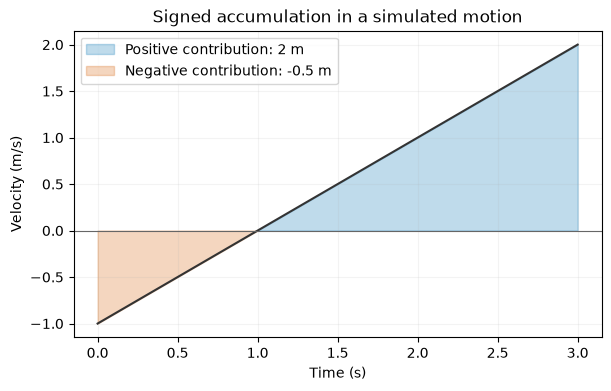

In [5]:
def primitive_velocity(t):
    return t**2 / 2 - t


# 在速度变号点 t=1 拆分积分，位移相加，路程将负贡献反号。
negative_part = primitive_velocity(1) - primitive_velocity(0)
positive_part = primitive_velocity(3) - primitive_velocity(1)
print("位移（m）：", negative_part + positive_part)  # 1.5。
print("路程（m）：", -negative_part + positive_part)  # 2.5。

t = np.linspace(0, 3, 301)
velocity = t - 1
fig, ax = plt.subplots(figsize=(6, 3.8), layout="constrained")
ax.plot(t, velocity, color="#333333")
# 用布尔掩码分别填充零线上下的区域，保留积分贡献的正负。
ax.fill_between(
    t,
    velocity,
    0,
    where=velocity >= 0,
    color="#0072B2",
    alpha=0.25,
    label="Positive contribution: 2 m",
)
ax.fill_between(
    t,
    velocity,
    0,
    where=velocity <= 0,
    color="#D55E00",
    alpha=0.25,
    label="Negative contribution: -0.5 m",
)
ax.axhline(0, color="#666666", linewidth=0.8)
ax.set(
    xlabel="Time (s)",
    ylabel="Velocity (m/s)",
    title="Signed accumulation in a simulated motion",
)
ax.legend()
ax.grid(alpha=0.15)
# 预期 0～1 s 阴影在零线下、1～3 s 在零线上，贡献分别为 -0.5 m、2 m。
plt.show()

## 5 换元把复合表达式化简

换元对应求导中的链式法则。若 $g'$ 在 $[a,b]$ 连续，f 在 g 的取值范围上连续，令 $u=g(x)$，有

$$\int_a^b f(g(x))g'(x)\,dx=\int_{g(a)}^{g(b)}f(u)\,du.$$

换元时同时换积分变量、导数因子和上下限。例如

$$\int_0^1\frac{2x}{1+x^2}\,dx
=\int_1^2\frac1u\,du=\ln2,$$

这里 $u=1+x^2$、$du=2x\,dx$。分母在整个区间为正，ln 有定义。也可直接写原函数 $\ln(1+x^2)$；其导数为 $2x/(1+x^2)$。不能只把分母改名而遗漏 $2x\,dx$，也不能换变量后仍使用原来的 0、1 上下限。

In [6]:
original_endpoints = np.log(1 + 1**2) - np.log(1 + 0**2)
changed_endpoints = np.log(2) - np.log(1)
print("原变量端点计算：", original_endpoints)  # 预期约为 0.693147。
print("新变量端点计算：", changed_endpoints)  # 都约为 0.693147。

原变量端点计算： 0.6931471805599453
新变量端点计算： 0.6931471805599453


## 6 分部积分把乘积拆开

若实函数 u、v 在 $[a,b]$ 上有连续导数，由乘积求导 $(uv)'=u'v+uv'$，两侧积分并移项，得到

$$\int_a^b u(x)v'(x)\,dx
=[u(x)v(x)]_a^b-\int_a^b u'(x)v(x)\,dx.$$

方括号 $[G(x)]_a^b$ 表示 $G(b)-G(a)$。分部积分的目的，是把原来的积分变为更容易处理的一个；不是每种拆法都会简化。

计算 $\int_0^1xe^x\,dx$ 时取 $u=x$、$v'=e^x$，于是 $u'=1$、$v=e^x$：

$$\int_0^1xe^x\,dx=[xe^x]_0^1-\int_0^1e^x\,dx
=e-(e-1)=1.$$

In [7]:
def primitive_product(x):
    return (x - 1) * np.exp(x)


print("分部积分的端点值：", primitive_product(1) - primitive_product(0))  # 1。
x = np.array([0.0, 0.5, 1.0])
derivative_expanded = np.exp(x) + (x - 1) * np.exp(x)
print("对原函数求导后的差：", derivative_expanded - x * np.exp(x))  # 预期为 [0. 0. 0.]。
# 差应接近零；检查原函数的导数可帮助发现符号或边界项错误。

分部积分的端点值： 1.0
对原函数求导后的差： [0. 0. 0.]


## 7 反常积分：先截断，再取极限

无穷区间或无界被积函数不能直接套用连续函数在有限闭区间上的结论。反常积分（improper integral）先避开无穷端点或奇点，计算普通定积分，再取极限。

例如，若 f 在 $[a,+\infty)$ 连续，a 为有限实数，则定义

$$\int_a^{+\infty}f(x)\,dx
=\lim_{R\to+\infty}\int_a^R f(x)\,dx.$$

R 是大于 a 的有限截断上限。极限为有限实数时称为收敛，否则称为发散。以下 x、R 均无单位：

$$\int_1^R\frac{1}{x^2}\,dx=1-\frac1R\longrightarrow1,
\qquad \int_1^R\frac1x\,dx=\ln R\longrightarrow+\infty.$$

两条曲线都趋于零，但累积量的极限不同。有限次截断计算只用来观察这些解析结论。

In [8]:
cutoffs = np.array([2.0, 10.0, 100.0, 1000.0])
convergent_totals = 1 - 1 / cutoffs
divergent_totals = np.log(cutoffs)
print("上限 R、1/x² 的累积、1/x 的累积：")
# 4×3 表中，第二列从 0.5 增至 0.999，靠近 1；第三列从约 0.693 增至 6.908。
print(np.column_stack((cutoffs, convergent_totals, divergent_totals)))
# 前者依次为 0.5、0.9、0.99、0.999，尾部缺少的累积恰为 1/R。
# 后者持续增加；任意有限 R 的结果有限，不表示反常积分收敛。

上限 R、1/x² 的累积、1/x 的累积：
[[2.00000000e+00 5.00000000e-01 6.93147181e-01]
 [1.00000000e+01 9.00000000e-01 2.30258509e+00]
 [1.00000000e+02 9.90000000e-01 4.60517019e+00]
 [1.00000000e+03 9.99000000e-01 6.90775528e+00]]


### 7.1 端点无界不一定导致积分发散

若 f 在 $(a,b]$ 连续但在左端无界，a、b 为有限实数且 $a<b$，则考察

$$\int_a^b f(x)\,dx=\lim_{\varepsilon\to0^+}
\int_{a+\varepsilon}^b f(x)\,dx,\qquad 0<\varepsilon<b-a.$$

$\varepsilon$ 是避开端点的正距离。对无单位区间 $(0,1]$，

$$\int_\varepsilon^1 x^{-1/2}\,dx=2(1-\sqrt\varepsilon)\longrightarrow2,
\qquad \int_\varepsilon^1 x^{-1}\,dx=-\ln\varepsilon\longrightarrow+\infty.$$

不能把 0 直接代入这两个被积函数，也不能仅凭“端点无界”判定两者都发散。若奇点位于区间内部，应在该点分开取两侧极限，要求两边分别收敛。

整个实轴上的积分也应在一个有限点拆开，分别处理两端。对称截断可能把两个发散部分抵消，不能用这种抵消代替两边分别收敛的条件。

In [9]:
endpoint_gaps = np.array([0.1, 0.01, 0.0001])
root_totals = 2 * (1 - np.sqrt(endpoint_gaps))
log_totals = -np.log(endpoint_gaps)
print("端点距离、1/√x 的累积、1/x 的累积：")
print(np.column_stack((endpoint_gaps, root_totals, log_totals)))  # 3×3 表中，第二列约 1.36754、1.8、1.98，靠近 2；第三列继续增大。
# 只计算正端点下的原函数差，没有在零处调用被积函数。
# 第一列对应的 root_totals 趋近 2；log_totals 无有限极限。
print("1/(2√x) 的截断累积：", root_totals / 2)  # 预期约为 [0.683772 0.9 0.99 ]。
# 乘以 1/2 后，总积分为 1：函数局部无界与总累积有限可以同时成立。

端点距离、1/√x 的累积、1/x 的累积：
[[1.00000000e-01 1.36754447e+00 2.30258509e+00]
 [1.00000000e-02 1.80000000e+00 4.60517019e+00]
 [1.00000000e-04 1.98000000e+00 9.21034037e+00]]
1/(2√x) 的截断累积： [0.68377223 0.9        0.99      ]


## 8 用梯形连接离散采样

只知道采样值时，不能直接调用原函数。设横坐标严格递增为 $x_0,\ldots,x_n$，$y_i=f(x_i)$，用相邻点间的直线代替曲线，每段的带符号梯形面积为

$$\frac{y_i+y_{i+1}}2(x_{i+1}-x_i).$$

复合梯形法把这些面积相加，$T=\sum_{i=0}^{n-1}(y_i+y_{i+1})(x_{i+1}-x_i)/2$。NumPy 的 np.trapezoid(y, x=x) 实现此计算；一维 x、y 长度相同。本例给 $f(x)=x^2$ 的 3 个采样点，积分区间为 $[0,1]$，解析值是 $1/3$。

In [10]:
x = np.array([0.0, 0.5, 1.0])
y = x**2
pieces = (y[:-1] + y[1:]) / 2 * np.diff(x)
manual = np.sum(pieces)
library = np.trapezoid(y, x=x)
print("每段贡献：", pieces)  # 0.0625、0.3125。
print("手算形式与 NumPy：", manual, library)  # 都为 0.375。
print("与 1/3 的绝对误差：", abs(library - 1 / 3))  # 预期约为 0.0416667。

每段贡献： [0.0625 0.3125]
手算形式与 NumPy： 0.375 0.375
与 1/3 的绝对误差： 0.041666666666666685


### 8.1 不等间距与输入顺序

np.trapezoid 不会自动排序 x，而是按给定顺序累加。x 递减会反向积分；无意乱序则会改变所计算的路径。若观测表需要按横坐标排序，必须同时重排对应的 y，保留每行关系。

等间距数据可用 dx 指定间距；省略 x 和 dx 时默认每段宽度为 1。这个默认值不代表“自动识别一秒”。不等间距应显式传入 x。

In [11]:
irregular_x = np.array([0.0, 0.2, 1.0])
irregular_y = irregular_x**2
print("使用实际间距：", np.trapezoid(irregular_y, x=irregular_x))  # 0.42。
print("反向顺序：", np.trapezoid(irregular_y[::-1], x=irregular_x[::-1]))  # -0.42。
print("省略间距：", np.trapezoid(irregular_y))  # 0.54，计算的是不同的横坐标。

使用实际间距： 0.42000000000000004
反向顺序： -0.42000000000000004
省略间距： 0.54


### 8.2 用已知答案观察误差

当 f 在 $[a,b]$ 上二阶连续可导，且 $|f''(x)|\le M$，等分 n 段的梯形误差满足

$$\left|\int_a^b f(x)\,dx-T_n\right|\le\frac{M(b-a)^3}{12n^2}.$$

这里 M 是整个区间上的二阶导数绝对值上界。该式描述精确函数值与数学求积公式的离散误差，不包含测量噪声或浮点舍入。

对 $x^2$ 在 $[0,1]$ 上积分，$f''=2$，上界为 $1/(6n^2)$。把 n 加倍，理论上界变为四分之一；本例实际离散误差恰好等于这个界。一般函数不必达到上界，也不能在缺乏光滑条件时照搬它。

n= 2，绝对误差=0.04166667，理论界=0.04166667
n= 4，绝对误差=0.01041667，理论界=0.01041667
n= 8，绝对误差=0.00260417，理论界=0.00260417
n=16，绝对误差=0.00065104，理论界=0.00065104
n=32，绝对误差=0.00016276，理论界=0.00016276


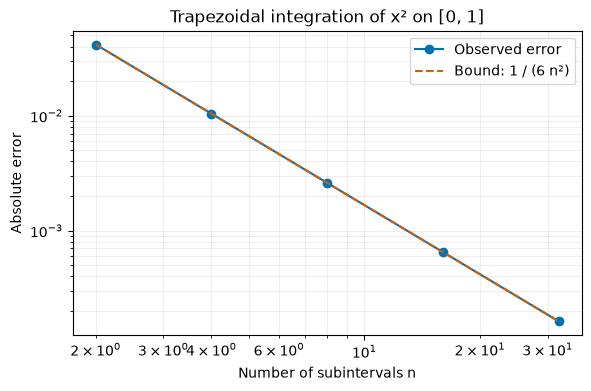

In [12]:
counts = np.array([2, 4, 8, 16, 32])
errors = []
# n 是子区间数，因此需要 n+1 个端点；每次都与同一个解析值比较。
for n in counts:
    nodes = np.linspace(0, 1, n + 1)
    estimate = np.trapezoid(nodes**2, x=nodes)
    error = abs(estimate - 1 / 3)
    bound = 1 / (6 * n**2)
    errors.append(error)
    print(f"n={n:2d}，绝对误差={error:.8f}，理论界={bound:.8f}")  # 本例每次误差等于给出的理论界；n 翻倍，误差约变为原来的 1/4。

# 实测误差与理论界使用相同横轴；对数坐标展示随 n 改变的尺度。
fig, ax = plt.subplots(figsize=(5.8, 3.8), layout="constrained")
ax.loglog(counts, errors, "o-", color="#0072B2", label="Observed error")
ax.loglog(counts, 1 / (6 * counts**2), "--", color="#D55E00", label="Bound: 1 / (6 n²)")
ax.set(
    xlabel="Number of subintervals n",
    ylabel="Absolute error",
    title="Trapezoidal integration of x² on [0, 1]",
)
ax.legend()
ax.grid(alpha=0.2, which="both")
# 预期实测点与理论界虚线重合；n 翻倍时误差约缩小为 1/4。
plt.show()  # 实测点与界重合；这幅图展示给定函数的数值结果。

## 9 函数求积与采样求积使用不同入口

SciPy 的 integrate.quad 接收可调用函数和积分上下限，可根据需要在区间内继续计算函数值。返回值是积分近似和绝对误差估计；后者不是解析证明，也不是关于测量噪声的置信区间。

epsabs 与 epsrel 分别设置绝对和相对精度目标。若真实积分为 I、返回结果为 q，算法尝试满足 $|I-q|\le\max(\mathrm{epsabs},\mathrm{epsrel}|I|)$。下面先对连续函数的有限区间积分作核对。quad 也接受无穷上下限，但这不免除收敛性判断；不要忽略警告，也不要把返回数值当成收敛证明。

选取已手算的 $\int_0^1xe^x\,dx=1$，同时比较真实误差与返回的误差估计。选择 $10^{-10}$ 是针对本例约为 1 的数值尺度，不是通用阈值。

In [13]:
from scipy.integrate import quad


def product_function(x):
    return x * np.exp(x)


result, estimated_error = quad(product_function, 0, 1, epsabs=1e-10, epsrel=1e-10)
print("quad 近似：", result)  # 预期积分接近解析值 1；本次 quad 返回 1.0。
print("返回的绝对误差估计：", estimated_error)  # 本次数值约为 1.1e-14。
print("与已知答案 1 的绝对差：", abs(result - 1))  # 预期接近 0；本次计算为 0。
# 本例结果应接近 1；误差估计与实际差是两个不同的量。

quad 近似： 1.0
返回的绝对误差估计： 1.1102230246251565e-14
与已知答案 1 的绝对差： 0.0


### 9.1 Simpson 法利用局部二次曲线

复合 Simpson 法在相邻三个点上使用二次插值。等间距且 n 为正偶数时，令 $h=(b-a)/n$、$y_i=f(a+ih)$，有

$$S_n=\frac h3\left[y_0+y_n+4\sum_{\substack{1\le i<n\\i\text{ 为奇数}}}y_i+2\sum_{\substack{2\le i<n\\i\text{ 为偶数}}}y_i\right].$$

因此这里使用奇数个采样点。scipy.integrate.simpson 接收已采样的 y 和 x；等间距奇数点时，对次数不超过 3 的多项式，数学公式精确，浮点计算仍可有舍入误差。非等间距时不能套用同一个权重公式；更多采样点也不能自动修复错误单位、排序或输入噪声。

In [14]:
from scipy.integrate import simpson

x = np.linspace(0, 1, 5)  # 4 段、5 点，h = 0.25。
y = x**3
h = 0.25
weighted = h / 3 * (y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]))
print("显式 Simpson 权重：", weighted)  # 预期约为 0.25。
print("SciPy Simpson：", simpson(y, x=x))  # 两者接近解析值 0.25。
print("相同采样的梯形近似：", np.trapezoid(y, x=x))  # 0.265625。

显式 Simpson 权重： 0.25
SciPy Simpson： 0.25
相同采样的梯形近似： 0.265625


## 10 综合实践：由模拟速度表估计位移

设 $v(t)=2+t^2$ m/s，t 以秒计，观察 $[0,2]$ 秒。解析位移为 $[2t+t^3/3]_0^2=20/3$ m。先把这个已知函数当作模拟真值，再只保留不等间距的 5 个采样点，考察采样带来的误差。

位移需要每个间隔内的累积。cumulative_trapezoid(..., initial=0) 返回从首点开始的累计梯形结果，长度与原采样点相同；起始 0 表示相对首时刻的位移，不是给定绝对位置。

比较解析值、函数求积、采样求积与加密采样。加密这里意味着重新从已知教学函数获取更多读数；对真实测量表，仅插入线性插值点不会得到新的观测，也不会修复尚未测到的变化。

In [15]:
from scipy.integrate import cumulative_trapezoid


def model_speed(t):
    return 2 + t**2


# 采样间距不相等，必须传入实际时间；initial=0 使累计结果与时间一一对应。
sample_times = np.array([0.0, 0.3, 0.9, 1.4, 2.0])
sample_speeds = model_speed(sample_times)
cumulative = cumulative_trapezoid(sample_speeds, x=sample_times, initial=0)
truth = 20 / 3
callable_result, callable_error = quad(model_speed, 0, 2)
# 加密采样和直接函数求积分别计算，再与已知解析位移核对。
dense_times = np.linspace(0, 2, 101)
dense_result = np.trapezoid(model_speed(dense_times), x=dense_times)

# 5×3 表依次列时间 s、速度 m/s、累计位移 m；末行为 [2, 6, 6.764]。
print(
    "时间、速度、累计位移：", np.column_stack([sample_times, sample_speeds, cumulative])
)
print("解析位移（m）：", truth)  # 预期约为 6.66667。
print("函数求积（m）：", callable_result)  # 预期约为 6.66667。
print("5 点采样估计与误差（m）：", cumulative[-1], cumulative[-1] - truth)  # 预期约为 6.764 0.0973333。
print("101 点采样估计与误差（m）：", dense_result, dense_result - truth)  # 预期约为 6.6668 0.000133333。
# 两种梯形估计都略大于真值；加密后误差变小，quad 应接近 20/3。

时间、速度、累计位移： [[0.     2.     0.    ]
 [0.3    2.09   0.6135]
 [0.9    2.81   2.0835]
 [1.4    3.96   3.776 ]
 [2.     6.     6.764 ]]
解析位移（m）： 6.666666666666667
函数求积（m）： 6.666666666666667
5 点采样估计与误差（m）： 6.764000000000001 0.09733333333333416
101 点采样估计与误差（m）： 6.6668 0.00013333333333331865


累计图在每个采样时刻核对位移；原始速度图显示间隔和曲线形状。两图纵轴单位分别是 m/s 和 m，不能把同一数值刻度当成同一种量。图上的连线只连接计算点，教学真值曲线另行绘出。

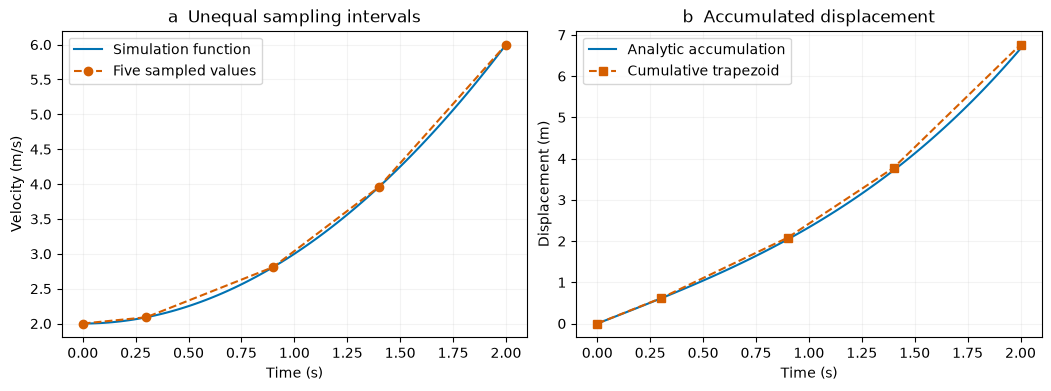

In [16]:
# 左图比较速度曲线与五个采样点，右图比较它们对应的累计位移。
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.8), layout="constrained")
axes[0].plot(
    dense_times, model_speed(dense_times), color="#0072B2", label="Simulation function"
)
axes[0].plot(
    sample_times, sample_speeds, "o--", color="#D55E00", label="Five sampled values"
)
axes[0].set(
    xlabel="Time (s)", ylabel="Velocity (m/s)", title="a  Unequal sampling intervals"
)
# 解析累积为 2t+t³/3；与梯形累计值共用位移单位 m。
axes[1].plot(
    dense_times,
    2 * dense_times + dense_times**3 / 3,
    color="#0072B2",
    label="Analytic accumulation",
)
axes[1].plot(
    sample_times, cumulative, "s--", color="#D55E00", label="Cumulative trapezoid"
)
axes[1].set(
    xlabel="Time (s)", ylabel="Displacement (m)", title="b  Accumulated displacement"
)
for ax in axes:
    ax.grid(alpha=0.15)
    ax.legend()
# 预期五点折线位于凸速度曲线上方；末端梯形位移约 6.764 m，高于解析值约 6.667 m。
plt.show()

## 本章小结

（1）定积分来自带宽度的累积和，单位是被积量单位乘积分变量单位。带符号累积与绝对值累积表达不同目标。

（2）连续条件下，微积分基本定理把积分与原函数联系起来；换元要转换上下限和导数因子，分部积分要保留边界项。

（3）采样求积必须核对横坐标、间距与排序。梯形和 Simpson 使用现有采样，quad 则需要能继续计算的函数。

（4）解析误差界、算法给出的误差估计和已知答案下的实际差不能混为一谈。测量误差与模型假设也不能仅靠加密计算消除。

（5）无穷区间和无界端点用反常积分的极限处理。被积函数趋于零、某次截断值有限，都不足以判断收敛。

自查：速度有负值时，位移和路程为什么不同？只给五条观测时，能否凭空让 quad 获得更多真实测量？

## 练习

（1）对 $f(x)=3x^2$ 在 $[0,2]$ 上积分，先求原函数与解析值，再使用 5、9、17 个等距点比较梯形和 Simpson。解释两者误差为什么不同，列出 Simpson 在这里使用的采样条件。

In [17]:
sample_counts = [5, 9, 17]
# 补充解析积分、两种采样求积及绝对误差；不要只输出“没有报错”。

（2）教学速度为 $v(t)=2-t$ m/s，时间为 $0\le t\le5$ 秒。分别计算位移和路程，画图标出变号点，并说明为什么路程不能取成“位移的绝对值”。核对时按变号点拆分积分。

In [18]:
exercise_times = np.linspace(0, 5, 101)
exercise_velocity = 2 - exercise_times
# 补充解析分段计算、图形及两种累积的解释。

（3）已知下列不等间距的教学功率观测，横坐标单位为秒，功率单位为 W。用梯形法估计总能量，写明结果的单位；比较省略 x 时的结果，并解释两者差异。再给出一个不能仅凭四个采样点断言积分精确的理由。

In [19]:
times_seconds = np.array([0.0, 1.0, 3.0, 4.0])
powers_watts = np.array([2.0, 3.0, 5.0, 4.0])
# 补充每段贡献和总和；用单位关系核对数值的含义。

（4）计算 $\int_0^1 3x^2e^{x^3}\,dx$：写出换元及新上下限，再用 quad 与解析结果核对。另有人说“quad 的误差估计很小，所以输入函数必定符合真实测量”，指出这句话混淆了哪些问题。

In [20]:
def exercise_function(x):
    return 3 * x**2 * np.exp(x**3)


# 补充换元推导、数值求积、误差比较和条件解释。

（5）分别考察 $I(R)=\int_1^R x^{-2}\,dx$ 与 $J(R)=\int_1^R x\,x^{-2}\,dx$，其中 $R>1$。先手算，再选递增的 R 核对。原函数的总累积有限，是否保证乘以 x 后的加权累积仍有限？

核对标准：写出两个截断积分与极限；用收敛条件解释结论，不用某次有限输出代替极限。

In [21]:
exercise_cutoffs = np.array([10.0, 100.0, 1000.0])
# 先写出两个原函数，再计算有限上限下的累积，并分别说明极限。

## 练习提示与解析

以下对应练习（5）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：分别写出两个积分在有限上限 R 下的值。

提示 2：乘以 x 会改变尾部的衰减速度；不能沿用原被积函数的收敛结论。

### 练习（5）参考解析

当 $R>1$ 时，$I(R)=\int_1^R x^{-2}\,dx=1-1/R$，所以 $\lim_{R\to+\infty}I(R)=1$。而 $J(R)=\int_1^R x\,x^{-2}\,dx=\ln R$，随 R 增大无界，因此第二个反常积分发散。

原来的总累积有限，并不保证乘以 x 后的加权累积有限。每个有限 R 下，两者都能算出有限数；判断反常积分仍须考察极限，而不是只检查某个截断结果。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax | Calculus Volume 1：[§5.2 The Definite Integral](https://openstax.org/books/calculus-volume-1/pages/5-2-the-definite-integral) 的 Definition、Theorem 5.1、Net Signed Area 与积分性质；[§5.3 The Fundamental Theorem of Calculus](https://openstax.org/books/calculus-volume-1/pages/5-3-the-fundamental-theorem-of-calculus) 的 Theorems 5.4–5.5、链式法则与变上限；[§5.5 Substitution](https://openstax.org/books/calculus-volume-1/pages/5-5-substitution) 的 Theorems 5.7–5.8。Calculus Volume 2：[§3.1 Integration by Parts](https://openstax.org/books/calculus-volume-2/pages/3-1-integration-by-parts) 的 Theorem 3.1 与式 (3.2)；[§3.6 Numerical Integration](https://openstax.org/books/calculus-volume-2/pages/3-6-numerical-integration) 的梯形法、Theorem 3.5 误差界与 Simpson's Rule。[§3.7 Improper Integrals](https://openstax.org/books/calculus-volume-2/pages/3-7-improper-integrals) 的 Definitions、式 (3.16)–(3.21)：无穷区间、无界端点、分段极限与收敛条件。本章使用自制数据与推导示例，不复制原书图形。 |
| NumPy 官方文档 | NumPy 2.5：[trapezoid](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html) 的 x、dx、按给定顺序积分及反向示例。 |
| SciPy 官方文档 | SciPy 1.18：[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) 的 callable 输入、无穷上下限、返回值、epsabs/epsrel 与 Notes；[simpson](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.simpson.html) 的采样参数和 Notes 中精确性条件；[cumulative_trapezoid](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.cumulative_trapezoid.html) 的 x、initial 与返回形状。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.fill_between](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html) 的 where 条件填充，用于显示正负速度贡献。 |